## Imports

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats import rankdata, wilcoxon, zscore
from tqdm.notebook import trange

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR
from analysis_helpers.functions import mean_center, show_source

## Functions

In [2]:
show_source(mean_center)

In [3]:
def rdp(trajectory, epsilon, metric='cosine', return_indices=False):
    """
    Simplify an n-dimensional trajectory using the Ramer-Douglas-Peucker 
    algorithm.

    Parameters
    ----------
    trajectory : numpy.ndarray
        A (timepoints x features) matrix representing the curve to 
        simplify.
    epsilon : float
        Maximum allowed distance from a point to the simplified curve. 
        Points farther than epsilon from the line segment connecting 
        their neighbors are retained.
    metric : str or callable
        Distance metric used when computing point-to-segment distances.
        Accepts any distance name supported by 
        scipy.spatial.distance.cdist (e.g. 'euclidean', 'cosine', 
        'correlation') or a callable with signature f(u, v) -> float.
    return_indices : bool, default False
        If True, return a tuple (simplified_trajectory, indices) where
        indices is a 1D array of the retained points' indices in the 
        original trajectory. Else return only the simplified trajectory.

    Returns
    -------
    numpy.ndarray or tuple
        The simplified trajectory, or (simplified_trajectory, indices) 
        when return_indices is True.
    """
    def _dist(points, start, end):
        """
        Compute the distance from each point in `points` to the line 
        segment defined by `start` and `end`.

        Perpendicular foot is clamped to the segment so points past
        either endpoint are measured to the nearest endpoint.
        """
        segment = end - start
        seg_len_sq = np.dot(segment, segment)

        if seg_len_sq == 0:
            # Degenerate segment: start == end; distance is point-to-point
            if callable(metric):
                return np.array([metric(p, start) for p in points])
            return cdist(points, start[np.newaxis], metric=metric).ravel()

        # Scalar projection of each point onto the segment, clamped to [0, 1].
        t = np.clip(np.dot(points - start, segment) / seg_len_sq, 0.0, 1.0)
        projections = start + t[:, np.newaxis] * segment

        if callable(metric):
            return np.array(
                [metric(p, proj) for p, proj in zip(points, projections)]
            )
        return cdist(points, projections, metric=metric).diagonal()

    def _rdp_indices(indices):
        """Recursively collect indices of points to keep."""
        if len(indices) <= 2:
            return list(indices)

        start = trajectory[indices[0]]
        end = trajectory[indices[-1]]
        inner = indices[1:-1]

        dists = _dist(trajectory[inner], start, end)
        max_idx = np.argmax(dists)
        max_dist = dists[max_idx]

        if max_dist > epsilon:
            pivot = max_idx + 1
            left = _rdp_indices(indices[:pivot + 1])
            right = _rdp_indices(indices[pivot:])
            # Merge, avoiding the duplicate at the pivot.
            return left[:-1] + right
        
        return [indices[0], indices[-1]]

    trajectory = np.asarray(trajectory)
    kept = _rdp_indices(list(range(len(trajectory))))
    kept = np.array(kept)

    simplified = trajectory[kept]
    return (simplified, kept) if return_indices else simplified

In [4]:
def eps_removal_pos(eps_at_removal, imm_recalled, omitted):
    """
    Probability of superiority for RDP-removability vs omission -- the 
    probability that an event omitted from delayed recall is removed 
    from immediate recall by RDP at a lower epsilon than one retained.
    """
    imm_recalled = list(imm_recalled)
    omitted = list(omitted)
    labels = np.isin(imm_recalled, omitted).astype(int)
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        raise ValueError(
            'need at least 1 omitted & 1 retained event to compute PoS'
            f'(n_omitted = {n_pos}, n_retained = {n_neg})'
        )
    
    # convert to "prominence" so removed earlier -> higher value 
    prominence = np.array([-eps_at_removal[ev] for ev in imm_recalled])
    ranks = rankdata(prominence)
    return (ranks[labels == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

In [16]:
def fit_logistic(design_mat, outcome):
    """Fit a logistic regression by MLE & return coefficients"""
    def _neg_ll(beta):
        logits = design_mat @ beta
        return np.sum(np.logaddexp(0, logits) - outcome * logits)
 
    return minimize(_neg_ll, np.zeros(design_mat.shape[1]), method='BFGS').x

## Load data

In [6]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [26]:
N_PERMS_P = 10_000
N_BOOTS_CI = 10_000

In [7]:
ep_events_centered = mean_center(atlep1.events)

# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

In [8]:
EPSILONS = np.arange(0, 2.1, 0.1).round(1)

rdp_data = []
for p_ix, p in enumerate(participants):
    imm_events = imm_events_centered[p_ix]
    imm_matches = p.event_matches['atlep1']
    del_matches = p.event_matches['delayed']
    
    # sweep over epsilons, record lowest at which each event is removed
    eps_at_removal = {}
    prev_retained = set(range(len(imm_events)))
    
    for eps in EPSILONS[1:].tolist():
        new_retained = set(rdp(imm_events, 
                               epsilon=eps, 
                               metric='cosine', 
                               return_indices=True)[1].tolist())
        if new_retained != prev_retained:
            for removed_event in prev_retained - new_retained:
                matched_ep_event = imm_matches[removed_event].item()
                eps_at_removal.setdefault(matched_ep_event, eps)
            prev_retained = new_retained
    
    # confirm all interior events were removed at some epsilon
    assert len(new_retained) == 2
    
    # RDP can't remove 1st or last events recalled, so exclude from pool
    imm_counts = Counter(imm_matches[1:-1].tolist())
    del_counts = Counter(del_matches.tolist())
    imm_endpoint_counts = Counter((int(imm_matches[0]), int(imm_matches[-1])))
    omitted = set(imm_counts - (del_counts - imm_endpoint_counts))
    
    rdp_data.append({
        'eps_at_removal': eps_at_removal,
        'omitted': omitted,
        'pool': set(imm_matches[1:-1].tolist())
    })

## Does RDP-removability from immediate recall predict omission from delayed recall?

In [42]:
participants_pos = []

for p_data in rdp_data:
    if len(p_data['omitted']) == 0:
        # need at least 1 omitted event to cmopute PoS
        continue
    
    pos = eps_removal_pos(p_data['eps_at_removal'], 
                          p_data['pool'], 
                          p_data['omitted'])
    participants_pos.append(pos)
        
T, p = wilcoxon(participants_pos, 0.5, alternative='greater')
T, p = T.item(), p.item()
print(f'mean probability of superiority: {np.mean(participants_pos):.3f}')
print(f'{T=}, {p=:.4f}')

mean probability of superiority: 0.576
T=846.0, p=0.0041


## Does RDP-removability from own immediate recall predict omission better than RDP-removability from *other* participants' immediate recalls?

In [10]:
own_win_rates = []

for i, p_target in enumerate(rdp_data):
    if len(p_target['omitted']) == 0:
        # need at least 1 omitted event to cmopute PoS
        continue

    target_eps_at_removal = p_target['eps_at_removal']
    target_omitted = p_target['omitted']
    
    target_wins = []
    for j, p_surrogate in enumerate(rdp_data):
        if i == j:
            continue
            
        # episode events both target and surrogate immediately recalled
        shared_pool = p_target['pool'] & p_surrogate['pool']
        if len(shared_pool & target_omitted) == 0:
            # surrogate must have immediately recalled at least 1 event 
            # the target participant omitted to compute PoS
            continue
            
        surr_eps_at_removal = p_surrogate['eps_at_removal']        
        pos_target = eps_removal_pos(target_eps_at_removal, shared_pool, target_omitted)
        pos_surrogate = eps_removal_pos(surr_eps_at_removal, shared_pool, target_omitted)
        if pos_target > pos_surrogate:
            target_wins.append(1)
        elif pos_target == pos_surrogate:
            target_wins.append(0.5)
        else:
            target_wins.append(0)
            
    own_win_rates.append(np.mean(target_wins))
    
T, p = wilcoxon(own_win_rates, 0.5, alternative='greater')
T, p = T.item(), p.item()
print(f'mean win rate: {np.mean(own_win_rates):.3f}')
print(f'{T=}, {p=:.4f}')

mean win rate: 0.614
T=864.5, p=0.0023


## Is RDP-removability predictiveness specific to own immediate recall geometry rather than episode geometry?

In [11]:
episode_eps_at_removal = {}
prev_retained = set(range(len(ep_events_centered)))
for eps in EPSILONS[1:].tolist():
    new_retained = set(rdp(ep_events_centered,
                           epsilon=eps,
                           metric='cosine',
                           return_indices=True)[1].tolist())
    if new_retained != prev_retained:
        for removed_event in prev_retained - new_retained:
            episode_eps_at_removal[removed_event] = eps
        prev_retained = new_retained

# confirm all events removed at some epsilon
assert len(new_retained) == 2

In [21]:
# construct matrix for regression
participant_ids = []
ep_event_ids = []
own_prominence_z = []
ep_prominence_z = []
omitted_labels = []

for p_ix, p_data in enumerate(rdp_data):
    # ensure 1st & last episode events are excluded if not matched by 
    # 1st & last recall events
    pool = sorted(p_data['pool'] - {0, len(atlep1.events) - 1})
    labels = np.isin(pool, list(p_data['omitted'])).astype(int)
    
    if labels.sum() in {0, len(labels)}:
        # need at least 1 omitted & 1 retained event to fit
        continue
    
    # convert to "prominence" so removed earlier -> higher value 
    own_prominence = np.array([-p_data['eps_at_removal'][ev] for ev in pool])
    ep_prominence = np.array([-episode_eps_at_removal[ev] for ev in pool])
    
    if own_prominence.std() == 0 or ep_prominence.std() == 0:
        # this never actually occurs, but would need to exclude 
        # participants whose interior events are all removed at the same 
        # epsilon
        continue
    
    participant_ids.extend([f'P{p_ix + 1}'] * len(pool))
    ep_event_ids.extend(pool)    
    own_prominence_z.extend(zscore(own_prominence))
    ep_prominence_z.extend(zscore(ep_prominence))
    omitted_labels.extend(labels)
    
participant_ids = np.array(participant_ids)
ep_event_ids = np.array(ep_event_ids)
own_prominence_z = np.array(own_prominence_z)
ep_prominence_z = np.array(ep_prominence_z)
omitted_labels = np.array(omitted_labels)

In [22]:
# fit logistic regression
intercept = np.ones(len(omitted_labels))
design_mat = np.column_stack([intercept, own_prominence_z, ep_prominence_z])
b_intercept, b_own_z, b_episode_z = fit_logistic(design_mat, omitted_labels)
b_intercept, b_own_z, b_episode_z = b_intercept.item(), b_own_z.item(), b_episode_z.item()

print('omitted ~ intercept + own_prominence_z + episode_prominence_z')
print(f'{b_intercept = :.3f}, {b_own_z = :.3f}, {b_episode_z = :.3f}')

omitted ~ intercept + own_prominence_z + episode_prominence_z
b_intercept = -1.397, b_own_z = 0.242, b_episode_z = 0.012


In [23]:
# participant-blocked permutation for p-values
SEED = 1

rng = np.random.default_rng(SEED)
blocks = [np.where(participant_ids == p)[0] for p in np.unique(participant_ids)]
null_coefs = np.empty((N_PERMS_P, 2))

for perm in trange(N_PERMS_P, leave=False):
    permuted = omitted_labels.copy()
    for block in blocks:
        permuted[block] = rng.permutation(permuted[block])
    null_coefs[perm] = fit_logistic(design_mat, permuted)[1:]
    
own_null, episode_null = null_coefs[:, 0], null_coefs[:, 1]

p_own = ((own_null >= b_own_z).sum() + 1) / (N_PERMS_P + 1)
p_episode = ((episode_null >= b_episode_z).sum() + 1) / (N_PERMS_P + 1)
p_own, p_episode = p_own.item(), p_episode.item()
print(f'{p_own = :.4f}, {p_episode = :.4f}')

  0%|          | 0/10000 [00:00<?, ?it/s]

p_own = 0.0053, p_episode = 0.4397


In [22]:
# rdp_upload_data = {
#     'episode_events': atlep1.events, 
#     'imm_rec_events': [p.events['atlep1'] for p in participants], 
#     'del_rec_events': [p.events['delayed'] for p in participants], 
#     'imm_event_matches': [p.event_matches['atlep1'] for p in participants], 
#     'del_event_matches': [p.event_matches['delayed'] for p in participants], 
#     'ep_path_2d': atlep1.path_2d, 
#     'imm_paths_2d': [p.paths_2d['atlep1'] for p in participants], 
#     'del_paths_2d': [p.paths_2d['delayed'] for p in participants]
# }

In [25]:
participants_pos

[np.float64(0.42857142857142855),
 np.float64(0.725),
 np.float64(0.765625),
 np.float64(0.625),
 np.float64(0.5641025641025641),
 np.float64(0.5641025641025641),
 np.float64(0.625),
 np.float64(0.5277777777777778),
 np.float64(0.6818181818181818),
 np.float64(0.8571428571428571),
 np.float64(0.5119047619047619),
 np.float64(0.375),
 np.float64(0.28125),
 np.float64(0.5151515151515151),
 np.float64(0.2222222222222222),
 np.float64(0.475),
 np.float64(0.7153846153846154),
 np.float64(0.6166666666666667),
 np.float64(0.87),
 np.float64(0.20512820512820512),
 np.float64(0.6333333333333333),
 np.float64(0.8571428571428571),
 np.float64(0.41346153846153844),
 np.float64(0.38),
 np.float64(0.55),
 np.float64(0.7019230769230769),
 np.float64(0.6428571428571429),
 np.float64(0.5178571428571429),
 np.float64(0.8571428571428571),
 np.float64(0.7666666666666667),
 np.float64(0.5256410256410257),
 np.float64(0.7692307692307693),
 np.float64(0.25),
 np.float64(0.6416666666666667),
 np.float64(0.669

In [ ]:
## ADDITIONAL IMPORTS
from matplotlib.patches import Polygon
from scipy.stats import gaussian_kde
 

## REMAINING QUANTITIES FOR THE FIGURE
# The three analyses above already produced most of what the figure displays:
#   participants_pos          -> panel C (per-participant probability of superiority)
#   own_win_rates             -> panel E (win-rate vs. surrogate participants)
#   b_own_z, b_episode_z      -> panel D (observed regression coefficients)
#   own_null, episode_null    -> panel D (permutation null distributions)
#   participants[i].paths_2d  -> panel B (an example participant's recall paths)
# This section adds only the quantities those analyses don't retain: bootstrap
# confidence intervals for the panel-C mean and the panel-D coefficients, and
# the own-within-k surrogate curve for panel F.
N_BOOTSTRAP = 10_000
 
# --- panel C: 95% bootstrap CI for the mean probability of superiority ---
pos_scores = np.asarray(participants_pos)
rng = np.random.default_rng(0)
boot_pos_means = [
    pos_scores[rng.integers(0, len(pos_scores), len(pos_scores))].mean()
    for _ in range(N_BOOTSTRAP)
]
pos_mean_ci = np.percentile(boot_pos_means, [2.5, 97.5])
 
# --- panel D: 95% cluster-bootstrap CIs for the regression coefficients ---
# Resample whole participants (not individual events) with replacement so the
# CIs respect the nesting of events within participants.
omitted_labels_arr = np.asarray(omitted_labels, dtype=float)
participant_ids_arr = np.asarray(participant_ids)
rows_by_participant = {
    pid: np.where(participant_ids_arr == pid)[0] for pid in np.unique(participant_ids_arr)
}
unique_participant_ids = list(rows_by_participant)
 
rng = np.random.default_rng(1)
boot_coefs = np.empty((N_BOOTSTRAP, design_mat.shape[1]))
for b in trange(N_BOOTSTRAP, leave=False):
    resampled = rng.choice(unique_participant_ids, len(unique_participant_ids), replace=True)
    rows = np.concatenate([rows_by_participant[pid] for pid in resampled])
    boot_coefs[b] = fit_logistic(design_mat[rows], omitted_labels_arr[rows])
own_coef_ci = np.percentile(boot_coefs[:, 1], [2.5, 97.5])
episode_coef_ci = np.percentile(boot_coefs[:, 2], [2.5, 97.5])
 
# --- panel F: is own removal-order among the best surrogate predictors? ---
# The win-rate analysis above keeps only each target's mean win-rate; the rank
# curve needs the per-comparison outcomes, so we re-run the target-vs-surrogate
# head-to-heads here (reusing rdp_data and eps_removal_pos). For each target we
# count how many surrogates beat it (n_below), tie it (n_ties), and are
# comparable at all (n_comparable). The observed curve is the fraction of targets
# whose own score lands within the top k; the chance curve is where a randomly
# ranked target would fall given its number of comparable surrogates.
n_below = []
n_ties = []
n_comparable = []
for target_ix, target in enumerate(rdp_data):
    if len(target['omitted']) == 0:
        continue
    losses = ties = comparable = 0
    for surrogate_ix, surrogate in enumerate(rdp_data):
        if surrogate_ix == target_ix:
            continue
        shared_pool = target['pool'] & surrogate['pool']
        if len(shared_pool & target['omitted']) == 0:
            # surrogate must share >= 1 of the target's omitted events to compare
            continue
        own_pos = eps_removal_pos(target['eps_at_removal'], shared_pool, target['omitted'])
        surr_pos = eps_removal_pos(surrogate['eps_at_removal'], shared_pool, target['omitted'])
        comparable += 1
        if surr_pos > own_pos:
            losses += 1
        elif surr_pos == own_pos:
            ties += 1
    n_below.append(losses)
    n_ties.append(ties)
    n_comparable.append(comparable)
n_below = np.array(n_below)
n_ties = np.array(n_ties)
n_comparable = np.array(n_comparable)
 
rank_cutoffs = np.arange(1, len(participants) + 1)
observed_within_k = np.array([
    np.mean(np.clip(k - n_below, 0, n_ties + 1) / (n_ties + 1)) for k in rank_cutoffs
])
chance_within_k = np.array([
    np.mean(np.minimum(k, n_comparable + 1) / (n_comparable + 1)) for k in rank_cutoffs
])
 

## FIGURE CONFIGURATION
# Every recurring colour / alpha / size / layout constant lives here so that
# colour-scheme or spacing experiments are one-stop edits.
 
# --- colours ---
EFFECT_COLOR       = '#cc4778'   # the effect (own prominence): fills & marks in panels C-F
COMPARE_COLOR      = '#8a8f98'   # comparison / null: episode (D), chance line (F)
REF_LINE_COLOR     = '#bbb'      # dashed reference lines at 0 / 0.5 (C, D, E)
PANEL_LETTER_COLOR = '#111'      # panel-letter labels
RECALL_PATH_COLOR  = '#333'      # recall-path lines (panel B)
DROP_LINK_COLOR    = 'black'     # dropped-event connectors / ghost links (panel B)
CI_BAR_COLOR       = 'black'     # mean +/- 95% CI bar (panel C)
BAND_COLOR         = '#409bff'   # epsilon band (panel A); at BAND_ALPHA over white == #bcdcff
EPISODE_COLORS     = plt.cm.Spectral(np.linspace(0, 1, 20))   # per-episode-event dot colours (panel B)
# cartoon palette (panel A)
CARTOON_CURVE_COLOR    = '#111'
CARTOON_ENDPOINT_COLOR = '#1565e0'
CARTOON_CHORD_COLOR    = '#12a5e5'
CARTOON_KEEP_COLOR     = '#2ec41f'
CARTOON_DROP_COLOR     = '#e8352b'
CARTOON_GHOST_COLOR    = '#b3b3b3'
CARTOON_FAINT_COLOR    = '#dfe3ea'   # faint copy of the original path
CARTOON_RING_COLOR     = '#666'      # ring highlighting the point under test
 
# --- alphas ---
VIOLIN_ALPHA     = 0.22   # C violin body
SWARM_ALPHA      = 0.8    # C per-participant swarm dots
CI_BAR_ALPHA     = 1.0    # C mean +/- 95% CI bar
NULL_FILL_ALPHA  = 0.18   # D permutation-null fills
NULL_EDGE_ALPHA  = 0.7    # D permutation-null outlines (kde style only)
HIST_ALPHA       = 0.4    # E histogram bars
TOPK_FILL_ALPHA  = 0.25   # F observed-vs-chance fill
DROP_GHOST_ALPHA = 0.2    # B dropped-event ghosts & shortcut lines
BAND_ALPHA       = 0.35   # A epsilon band
 
# --- sizes / fonts ---
EVENT_DOT_SIZE      = 150     # panel B event-dot size
RECALL_PATH_LW      = 1.2     # panel B path / connector linewidth
PANEL_LETTER_SIZE   = 17
PANEL_LETTER_WEIGHT = 'semibold'
PANEL_TITLE_SIZE    = 11      # panel B titles
LEGEND_SIZE         = 8
HIST_BAR_WIDTH      = 0.9     # E histogram bar-width fraction
SWARM_SIZE          = 4.5     # C seaborn swarm marker size (point diameter)
NULL_STYLE          = 'hist'  # D nulls: 'hist' (actual permutation coeffs) or 'kde' (smoothed)
NULL_HIST_BINS      = 41      # D bin count for the 'hist' style
NULL_HALF_WIDTH     = 0.40    # D half-width of the null distribution (extends +/- from 0)
OBSERVED_X          = 0.52    # D x-position of observed estimate + CI (episode -X, own +X)
 
# --- layout (inches) ---
PANEL_SIZE     = 3.0                                # side length of each square panel (B-F)
GAP_X          = 0.95                               # horizontal gap between columns
GAP_Y          = 0.70                               # vertical gap between rows
MARGIN         = 0.40                               # outer margin
CARTOON_WIDTH  = 1.3 * PANEL_SIZE                   # width of the panel-A cartoon column
STACK_HEIGHT   = 3 * PANEL_SIZE + 2 * GAP_Y         # full height of the 3-row panel stack
 
# --- derived styles ---
REF_LINE_STYLE = dict(color=REF_LINE_COLOR, ls='--', lw=1.2)   # null / chance reference line


## PANEL A SCHEMATIC (RDP recursion illustrated on a toy 2-D path)
# The cartoon is a hand-built schematic, not real data: it steps through the RDP
# recursion on a small 2-D path so the reader can see how points are kept or
# dropped relative to the epsilon tolerance band. It therefore uses its own
# 2-D (Euclidean) helpers rather than the cosine-distance rdp() used for the data.
CARTOON_PATH = np.array([
    [0.00, 0.50], [0.16, 0.53], [0.40, 0.65], [0.54, 0.47],
    [0.65, 0.42], [0.76, 0.54], [1.00, 0.50],
])
CARTOON_EPS = 0.05                            # tolerance used in the schematic
CARTOON_PAD_LEFT = CARTOON_PAD_RIGHT = 0.05   # horizontal padding around the path
 

def _point_segment_distance_2d(points, start, end):
    """Euclidean distance from each 2-D point to the segment start->end."""
    segment = end - start
    length_sq = float(segment @ segment)
    if length_sq == 0:
        return np.linalg.norm(points - start, axis=1)
    t = np.clip((points - start) @ segment / length_sq, 0, 1)
    projections = start + t[:, None] * segment
    return np.linalg.norm(points - projections, axis=1)
 

def _cartoon_final_kept(path, eps):
    """Indices RDP keeps for the toy path at tolerance eps (final simplification)."""
    def recurse(indices):
        if len(indices) <= 2:
            return list(indices)
        dists = _point_segment_distance_2d(path[indices[1:-1]], path[indices[0]], path[indices[-1]])
        farthest = int(np.argmax(dists))
        if dists[farthest] > eps:
            pivot = farthest + 1
            return recurse(indices[:pivot + 1])[:-1] + recurse(indices[pivot:])
        return [indices[0], indices[-1]]
    return sorted(recurse(list(range(len(path)))))
 

def _cartoon_recursion_steps(path, eps):
    """Record each RDP recursion step for the schematic. Each step is the segment
    under test (lo, hi), the farthest interior point (test), whether it clears
    epsilon (keep), and the kept/dropped sets accumulated so far."""
    kept = {0, len(path) - 1}
    dropped = set()
    steps = []
 
    def recurse(lo, hi):
        interior = list(range(lo + 1, hi))
        if not interior:
            return
        dists = _point_segment_distance_2d(path[interior], path[lo], path[hi])
        farthest_local = int(np.argmax(dists))
        farthest = interior[farthest_local]
        keep = dists[farthest_local] > eps
        steps.append(dict(lo=lo, hi=hi, test=farthest, keep=keep,
                          kept=set(kept), dropped=set(dropped)))
        if keep:
            kept.add(farthest)
            recurse(lo, farthest)
            recurse(farthest, hi)
        else:
            dropped.update(interior)
 
    recurse(0, len(path) - 1)
    return steps
 

def _epsilon_band_polygon(start, end, eps):
    """Corners of the +/- eps tolerance band around the chord start->end."""
    direction = end - start
    unit = direction / np.linalg.norm(direction)
    normal = np.array([-unit[1], unit[0]])
    return np.array([start + eps * normal, end + eps * normal,
                     end - eps * normal, start - eps * normal])
 

def draw_rdp_cartoon(ax, aspect):
    """Draw the panel-A schematic: a vertical stack of RDP recursion steps on the
    toy path, ending with the final simplified curve. `aspect` is the axes'
    width/height, used to size the vertical spacing so the stack fills the panel."""
    (x_min, y_min), (x_max, y_max) = CARTOON_PATH.min(0), CARTOON_PATH.max(0)
    x_span, y_span = x_max - x_min, y_max - y_min
    x_lo = x_min - CARTOON_PAD_LEFT * x_span
    x_hi = x_max + CARTOON_PAD_RIGHT * x_span
 
    steps = _cartoon_recursion_steps(CARTOON_PATH, CARTOON_EPS)
    final_kept = _cartoon_final_kept(CARTOON_PATH, CARTOON_EPS)
    final_dropped = [i for i in range(len(CARTOON_PATH)) if i not in final_kept]
    n_rows = len(steps) + 1                       # one row per recursion step + final result
 
    # vertical extent (keep the toy path's aspect ratio) and per-row centre lines
    height = (x_hi - x_lo) / aspect
    mid_y = (y_min + y_max) / 2
    y_top, y_bot = mid_y + height / 2, mid_y - height / 2
    margin = 0.03 * height
    first_center = y_top - margin - y_span / 2
    last_center = y_bot + margin + y_span / 2
    row_centers = [first_center - i * (first_center - last_center) / (n_rows - 1)
                   for i in range(n_rows)]
 
    def draw_segment(points, indices, color, lw, ls='-', z=1):
        pts = points[np.asarray(indices)]
        ax.plot(pts[:, 0], pts[:, 1], ls, color=color, lw=lw, zorder=z, solid_capstyle='round')
 
    def draw_points(points, indices, color, size):
        for i in indices:
            ax.scatter(*points[i], s=size, color=color, edgecolor='white', lw=0.7, zorder=5)
 
    def draw_ghost(points, i):
        ax.scatter(*points[i], s=55, color=CARTOON_GHOST_COLOR, edgecolor='white', lw=0.6, zorder=4)
 
    def draw_ring(points, i, kept):
        ax.scatter(*points[i], s=180, facecolor='none', edgecolor=CARTOON_RING_COLOR, lw=1.5, zorder=6)
        fill = CARTOON_KEEP_COLOR if kept else CARTOON_DROP_COLOR
        ax.scatter(*points[i], s=95, color=fill, edgecolor='white', lw=0.8, zorder=7)
 
    for row, center in enumerate(row_centers):
        path = CARTOON_PATH + np.array([0.0, center - mid_y])   # this row's shifted copy
 
        if row < len(steps):
            step = steps[row]
            lo, hi, tested, kept = step['lo'], step['hi'], step['test'], step['keep']
            kept_so_far, dropped_so_far = step['kept'], step['dropped']
 
            # faint copy of the original path (keeps dropped points linked to neighbours)
            draw_segment(path, range(len(CARTOON_PATH)), CARTOON_FAINT_COLOR, 1.4, z=0.5)
 
            # solid curve through the currently-kept points; endpoint-blue where a run is dropped
            marks = sorted(set(kept_so_far) | {lo, hi})
            for a, b in zip(marks, marks[1:]):
                interior = list(range(a + 1, b))
                if interior and all(j in dropped_so_far for j in interior):
                    draw_segment(path, [a, b], CARTOON_ENDPOINT_COLOR, 2.6, z=2)
                else:
                    draw_segment(path, range(a, b + 1), CARTOON_CURVE_COLOR, 2.0, z=1)
 
            # epsilon band + chord for the segment under test (behind everything but the band)
            ax.add_patch(Polygon(_epsilon_band_polygon(path[lo], path[hi], CARTOON_EPS),
                                 closed=True, facecolor=BAND_COLOR, edgecolor='none',
                                 alpha=BAND_ALPHA, zorder=0))
            ax.plot([path[lo, 0], path[hi, 0]], [path[lo, 1], path[hi, 1]],
                    color=CARTOON_CHORD_COLOR, lw=2.0, zorder=0.3, solid_capstyle='round')
 
            for j in range(len(CARTOON_PATH)):
                if j in dropped_so_far:
                    draw_ghost(path, j)
                elif j in kept_so_far or j in (lo, hi):
                    draw_points(path, [j], CARTOON_ENDPOINT_COLOR, 90)
                else:
                    draw_points(path, [j], CARTOON_CURVE_COLOR, 90)
            draw_ring(path, tested, kept)               # highlight the point being tested
 
        else:   # final row: the simplified curve
            draw_segment(path, range(len(CARTOON_PATH)), CARTOON_FAINT_COLOR, 1.4, z=0)
            draw_segment(path, final_kept, CARTOON_ENDPOINT_COLOR, 2.6, z=2)
            for j in final_dropped:
                draw_ghost(path, j)
            draw_points(path, final_kept, CARTOON_ENDPOINT_COLOR, 95)
 
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_bot, y_top)
    ax.set_aspect('equal')
    ax.axis('off')
 
 
## ASSEMBLE THE COMPOSITE FIGURE
# Layout: the panel-A cartoon runs full-height down the left; panels B-F fill a
# 2-columns x 3-rows block to its right (B top, C/D middle, E/F bottom).
EXAMPLE_PARTICIPANT_IX = 2   # participant shown in panel B ("P3")
 
fig_width = 2 * MARGIN + CARTOON_WIDTH + 2 * PANEL_SIZE + 2 * GAP_X
fig_height = 2 * MARGIN + STACK_HEIGHT
fig = plt.figure(figsize=(fig_width, fig_height))
 

def axes_rect(x, y, w, h):
    """Convert an (x, y, width, height) box in inches into a figure-fraction rect."""
    return [x / fig_width, y / fig_height, w / fig_width, h / fig_height]
 

def add_panel_letter(ax, label):
    ax.text(0.02, 0.98, label, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE,
            fontweight=PANEL_LETTER_WEIGHT, va='top', ha='left',
            color=PANEL_LETTER_COLOR, zorder=30)
 
 
col1_x = MARGIN + CARTOON_WIDTH + GAP_X          # left column of the B-F block
col2_x = col1_x + PANEL_SIZE + GAP_X             # right column
top_y = MARGIN + STACK_HEIGHT                    # top edge of the panel stack
 
# --- panel A: RDP schematic ---
ax_cartoon = fig.add_axes(axes_rect(MARGIN, MARGIN, CARTOON_WIDTH, STACK_HEIGHT))
draw_rdp_cartoon(ax_cartoon, aspect=CARTOON_WIDTH / STACK_HEIGHT)
add_panel_letter(ax_cartoon, 'A')
 
# --- panel B: an example participant's immediate vs. delayed recall paths ---
example = participants[EXAMPLE_PARTICIPANT_IX]
imm_path = example.paths_2d['atlep1']
imm_matches = example.event_matches['atlep1']
del_path = example.paths_2d['delayed']
del_matches = example.event_matches['delayed']
 

def draw_event_dot(ax, xy, episode_event, alpha=1.0, z=3):
    ax.scatter(xy[0], xy[1], s=EVENT_DOT_SIZE, color=EPISODE_COLORS[int(episode_event)],
               edgecolor='black', lw=1, alpha=alpha, zorder=z)
 
 
# immediate recall: faint shortcut lines bridge the events dropped by delayed recall
ax_imm = fig.add_axes(axes_rect(col1_x, top_y - PANEL_SIZE, PANEL_SIZE, PANEL_SIZE))
ax_imm.plot(imm_path[:, 0], imm_path[:, 1], '-', color=RECALL_PATH_COLOR, lw=RECALL_PATH_LW, zorder=1)
for before, after in [(13, 15), (9, 11)]:   # bridge across the dropped event between them
    start, end = imm_path[before - 1], imm_path[after - 1]
    ax_imm.plot([start[0], end[0]], [start[1], end[1]], '-', color=DROP_LINK_COLOR,
                lw=RECALL_PATH_LW, alpha=DROP_GHOST_ALPHA, zorder=1)
for j in range(len(imm_path)):
    draw_event_dot(ax_imm, imm_path[j], imm_matches[j])
ax_imm.set_aspect('equal')
ax_imm.axis('off')
ax_imm.set_title('P3 immediate recall', fontsize=PANEL_TITLE_SIZE)
add_panel_letter(ax_imm, 'B')
 
# delayed recall: ghost the dropped events at their immediate positions, linked to neighbours
ax_del = fig.add_axes(axes_rect(col2_x, top_y - PANEL_SIZE, PANEL_SIZE, PANEL_SIZE))
ax_del.plot(del_path[:, 0], del_path[:, 1], '-', color=RECALL_PATH_COLOR, lw=RECALL_PATH_LW, zorder=1)
for imm_ix, (del_before, del_after) in [(10, (9, 10)), (14, (12,13))]:
    ghost_xy = imm_path[imm_ix - 1]
    for del_ix in (del_before, del_after):
        neighbour = del_path[del_ix - 1]
        ax_del.plot([ghost_xy[0], neighbour[0]], [ghost_xy[1], neighbour[1]], '-',
                    color=DROP_LINK_COLOR, lw=RECALL_PATH_LW, alpha=DROP_GHOST_ALPHA, zorder=1)
    draw_event_dot(ax_del, ghost_xy, imm_matches[imm_ix - 1], alpha=DROP_GHOST_ALPHA, z=2)
for j in range(len(del_path)):
    draw_event_dot(ax_del, del_path[j], del_matches[j])
ax_del.set_aspect('equal')
ax_del.axis('off')
ax_del.set_title('P3 delayed recall', fontsize=PANEL_TITLE_SIZE)

# --- panel C: probability that forgotten events were removed earlier ---
ax_pos = fig.add_axes(axes_rect(col1_x, top_y - 2 * PANEL_SIZE - GAP_Y, PANEL_SIZE, PANEL_SIZE))
violin = ax_pos.violinplot([pos_scores], positions=[0], vert=True, showextrema=False, widths=0.85)
for body in violin['bodies']:
    body.set_facecolor(EFFECT_COLOR)
    body.set_alpha(VIOLIN_ALPHA)
    body.set_edgecolor(EFFECT_COLOR)
    body.set_linewidth(1.2)
sns.swarmplot(y=pos_scores, ax=ax_pos, color=EFFECT_COLOR, size=SWARM_SIZE,
              alpha=SWARM_ALPHA, edgecolor='white', linewidth=0.4, zorder=3)
ax_pos.axhline(0.5, **REF_LINE_STYLE)
ax_pos.errorbar([0], [pos_scores.mean()],
                yerr=[[pos_scores.mean() - pos_mean_ci[0]], [pos_mean_ci[1] - pos_scores.mean()]],
                fmt='o', color=CI_BAR_COLOR, ms=6, capsize=4, elinewidth=1.6, capthick=1.6,
                zorder=5, alpha=CI_BAR_ALPHA)
ax_pos.set_ylabel(r'$p$(forgotten events removed earlier)')
ax_pos.set_xticks([])
ax_pos.set_xlim(-0.7, 0.7)
for spine in ['top', 'right', 'bottom']:
    ax_pos.spines[spine].set_visible(False)
add_panel_letter(ax_pos, 'C')

# --- panel D: own vs. episode geometry regression ---
ax_reg = fig.add_axes(axes_rect(col2_x, top_y - 2 * PANEL_SIZE - GAP_Y, PANEL_SIZE, PANEL_SIZE))
null_bin_edges = np.linspace(min(own_null.min(), episode_null.min()),
                             max(own_null.max(), episode_null.max()), NULL_HIST_BINS + 1)
 

def draw_null_distribution(null_samples, side, color):
    """Draw one side of panel D's back-to-back permutation-null distribution."""
    if NULL_STYLE == 'kde':
        grid = np.linspace(null_samples.min(), null_samples.max(), 200)
        width = gaussian_kde(null_samples)(grid)
        width = width / width.max() * NULL_HALF_WIDTH
        ax_reg.fill_betweenx(grid, 0, side * width, color=color, alpha=NULL_FILL_ALPHA, lw=0)
        ax_reg.plot(side * width, grid, color=color, lw=1, alpha=NULL_EDGE_ALPHA)
    else:   # 'hist': the actual permutation coefficients
        counts, _ = np.histogram(null_samples, bins=null_bin_edges)
        centers = 0.5 * (null_bin_edges[:-1] + null_bin_edges[1:])
        heights = np.diff(null_bin_edges)
        width = counts / counts.max() * NULL_HALF_WIDTH
        ax_reg.barh(centers, side * width, height=heights, color=color,
                    alpha=NULL_FILL_ALPHA, lw=0, align='center')
 
 
draw_null_distribution(own_null, +1, EFFECT_COLOR)
draw_null_distribution(episode_null, -1, COMPARE_COLOR)
ax_reg.axhline(0, **REF_LINE_STYLE)
# observed coefficients + 95% CIs, flanking the nulls
ax_reg.plot([OBSERVED_X, OBSERVED_X], own_coef_ci, color=EFFECT_COLOR, lw=2.6, solid_capstyle='round')
ax_reg.scatter([OBSERVED_X], [b_own_z], s=70, color=EFFECT_COLOR, zorder=4, edgecolor='white', lw=1)
ax_reg.plot([-OBSERVED_X, -OBSERVED_X], episode_coef_ci, color=COMPARE_COLOR, lw=2.6, solid_capstyle='round')
ax_reg.scatter([-OBSERVED_X], [b_episode_z], s=70, color=COMPARE_COLOR, zorder=4, edgecolor='white', lw=1)
ax_reg.set_xlim(-0.82, 0.82)
ax_reg.set_ylim(-0.42, 0.46)
ax_reg.set_yticks([-0.4, -0.2, 0, 0.2, 0.4])
ax_reg.set_yticklabels(['-0.4', '-0.2', '0', '0.2', '0.4'])
ax_reg.set_xticks([-OBSERVED_X, OBSERVED_X])
ax_reg.set_xticklabels([r'$\epsilon_{episode}$', r'$\epsilon_{immediate\ recall}$'])
ax_reg.set_ylabel(r'$\beta$ (log-odds per SD)')
for spine in ['top', 'right']:
    ax_reg.spines[spine].set_visible(False)
add_panel_letter(ax_reg, 'D')
 
# --- panel E: win-rate against other participants ---
ax_winrate = fig.add_axes(axes_rect(col1_x, MARGIN, PANEL_SIZE, PANEL_SIZE))
ax_winrate.hist(own_win_rates, bins=np.linspace(0, 1, 16), color=EFFECT_COLOR,
                alpha=HIST_ALPHA, edgecolor='white', lw=0.5, rwidth=HIST_BAR_WIDTH)
ax_winrate.axvline(0.5, **REF_LINE_STYLE)
ax_winrate.set_xlabel('Fraction of others own beats')
ax_winrate.set_ylabel('Participants')
for spine in ['top', 'right']:
    ax_winrate.spines[spine].set_visible(False)
add_panel_letter(ax_winrate, 'E')
 
# --- panel F: is own removal-order among the top-k predictors? ---
ax_rank = fig.add_axes(axes_rect(col2_x, MARGIN, PANEL_SIZE, PANEL_SIZE))
ax_rank.fill_between(rank_cutoffs, chance_within_k, observed_within_k,
                     color=EFFECT_COLOR, alpha=TOPK_FILL_ALPHA, lw=0)
ax_rank.plot(rank_cutoffs, observed_within_k, color=EFFECT_COLOR, lw=2.2, label='Observed')
ax_rank.plot(rank_cutoffs, chance_within_k, '--', color=COMPARE_COLOR, lw=1.5, label='Chance')
ax_rank.set_xlabel(r'Rank cutoff $k$')
ax_rank.set_ylabel(r'Proportion within $k$ best')
ax_rank.set_xlim(1, len(participants))
ax_rank.set_ylim(0, 1)
ax_rank.legend(fontsize=LEGEND_SIZE, frameon=False, loc='lower right')
for spine in ['top', 'right']:
    ax_rank.spines[spine].set_visible(False)
add_panel_letter(ax_rank, 'F')
 
plt.savefig('rdp-figure.pdf', bbox_inches='tight')

In [305]:
"""
Compute every quantity the composite figure needs and cache it to
figure_panel_data.pkl.  Run this once (it does the RDP sweeps, the win-rate and
own-within-k surrogate loops, and the own-vs-episode regression with its
cluster bootstrap + participant-blocked permutation).  The figure script then
just loads the pickle and draws -- no recomputation while iterating on visuals.
"""
import pickle, numpy as np
from collections import Counter
from scipy.spatial.distance import cdist
from scipy.stats import rankdata, wilcoxon
from scipy.optimize import minimize

DATA="rdp_upload_data.p"; 
OUT="figure_panel_data.pkl"
EPS=np.arange(0,2,0.1).round(1); MAXEPS=2.0; P3=2; 
BOOT=10000
NPRM=10000
d=pickle.load(open(DATA,"rb")); NP=len(d["imm_rec_events"]); EP=d["episode_events"]

def mean_center(a,b):
    c=np.mean([a.mean(0),b.mean(0)],axis=0); return a-c,b-c
def rdp_ret(traj,eps,metric="cosine"):
    traj=np.asarray(traj)
    def dist(pts,s,e):
        seg=e-s; L=np.dot(seg,seg)
        if L==0: return cdist(pts,s[None],metric=metric).ravel()
        t=np.clip(np.dot(pts-s,seg)/L,0,1); pr=s+t[:,None]*seg; return cdist(pts,pr,metric=metric).diagonal()
    def rec(idx):
        if len(idx)<=2: return list(idx)
        dd=dist(traj[idx[1:-1]],traj[idx[0]],traj[idx[-1]]); k=int(np.argmax(dd))
        if dd[k]>eps: p=k+1; return rec(idx[:p+1])[:-1]+rec(idx[p:])
        return [idx[0],idx[-1]]
    return rec(list(range(len(traj))))
def removal_order(traj):
    n=len(traj); fre={}; prev=set(range(n))
    for e in EPS[1:]:
        ret=set(rdp_ret(traj,e))
        if ret!=prev:
            for j in prev-ret: fre.setdefault(j,e)
            prev=ret
    for j in range(1,n-1): fre.setdefault(j,EPS[-1])
    return fre
def forg_adj(P):
    im=d["imm_event_matches"][P]; dm=d["del_event_matches"][P]
    ii=Counter(im[1:-1].tolist()); da=Counter(dm.tolist()); en=Counter([int(im[0]),int(im[-1])])
    return set(e for e in ii if ii[e]>max(0,da.get(e,0)-en.get(e,0)))
def auc_sub(prom,subset,forg):
    lab=np.array([1 if e in forg else 0 for e in subset]); n1=int(lab.sum()); n0=len(lab)-n1
    if n1==0 or n0==0: return None
    r=rankdata(np.array([-prom[e] for e in subset])); return (r[lab==1].sum()-n1*(n1+1)/2)/(n1*n0)
def auc_scores(scores,labels):
    labels=np.asarray(labels); n1=int(labels.sum()); n0=len(labels)-n1
    if n1==0 or n0==0: return None
    r=rankdata(scores); return (r[labels==1].sum()-n1*(n1+1)/2)/(n1*n0)

# own removal order (episode-level, min-dedup), pools, forgotten
prom=[]; pools=[]
for P in range(NP):
    imm_c,_=mean_center(d["imm_rec_events"][P],d["del_rec_events"][P]); im=d["imm_event_matches"][P]; n=len(imm_c)
    fre=removal_order(imm_c); ef={}
    for j in range(1,n-1): ef[int(im[j])]=min(ef.get(int(im[j]),np.inf),fre[j])
    prom.append(ef); pools.append(set(Counter(im[1:-1].tolist()).keys()))
forgs=[forg_adj(P) for P in range(NP)]
valid=[P for P in range(NP) if 0<len(forgs[P]&pools[P])<len(pools[P])]

# per-participant probability of superiority (+ bootstrap CI of the mean)
aucs=np.array([auc_sub(prom[a],list(pools[a]),forgs[a]) for a in valid]); rng=np.random.default_rng(0)
auc_ci=np.percentile([np.mean(aucs[rng.integers(0,len(aucs),len(aucs))]) for _ in range(10_000)],[2.5,97.5])
auc_tp = wilcoxon(aucs-0.5,alternative="greater")
print(auc_tp)
print(auc_ci)
auc_p=auc_tp.pvalue

# Surrogate analyses (panels E and F) share ONE set of head-to-head comparisons: for
# each target participant a and each other participant b, restrict to the episode events
# both immediately recalled and compare a's own removal-order AUC against b's on that
# shared set (a's forgotten labels throughout). No max-eps fill.
#   E (win-rate): fraction of surrogates own beats.
#   F (within-k): rank own among those same head-to-head outcomes.
WR=[]; below=[]; ties=[]; ncomp=[]
for a in valid:
    ev=list(pools[a]); wins=lose=tie=0
    for b_ in range(NP):
        if b_==a: continue
        sh=[e for e in ev if e in prom[b_]]
        ao=auc_sub(prom[a],sh,forgs[a]); ab=auc_sub(prom[b_],sh,forgs[a])
        if ao is None or ab is None: continue          # no shared events with both classes
        if ao>ab: wins+=1
        elif ao<ab: lose+=1
        else: tie+=1
    nc=wins+lose+tie
    WR.append((wins+0.5*tie)/nc); below.append(lose); ties.append(tie); ncomp.append(nc)
WR=np.array(WR); WR_p=wilcoxon(WR-0.5,alternative="greater").pvalue
below=np.array(below); ties=np.array(ties); ncomp=np.array(ncomp)
M_=NP; ks=np.arange(1,M_+1)
observed=np.array([np.mean(np.clip(k-below,0,ties+1)/(ties+1)) for k in ks])   # own within top k
chance=np.array([np.mean(np.minimum(k,ncomp+1)/(ncomp+1)) for k in ks])        # null: own ranked at random among its comparable surrogates

# own-vs-episode event-level logistic (own_z + episode_z)
epfre=removal_order(EP-EP.mean(0)); pid=[]; oz=[]; ez=[]; yy=[]
for P in range(NP):
    ep_fre=prom[P]; fA=forgs[P]; pool=sorted(e for e in ep_fre if e in epfre); lab=np.array([1 if e in fA else 0 for e in pool])
    if len(pool)<4 or not(0<lab.sum()<len(lab)): continue
    ov=np.array([ep_fre[e] for e in pool],float); ev=np.array([epfre[e] for e in pool],float)
    if ov.std()==0 or ev.std()==0: continue
    for k in range(len(pool)): pid.append(P); oz.append(-(ov[k]-ov.mean())/ov.std()); ez.append(-(ev[k]-ev.mean())/ev.std()); yy.append(lab[k])
pid=np.array(pid); oz=np.array(oz); ez=np.array(ez); yy=np.array(yy,float); Xr=np.column_stack([np.ones(len(yy)),oz,ez])
def fitlr(Xm,yv):
    def nll(bb): z=Xm@bb; return np.sum(np.logaddexp(0,z)-yv*z)
    return minimize(nll,np.zeros(Xm.shape[1]),method="BFGS").x
reg_coef=fitlr(Xr,yy); ups=sorted(set(pid)); byp={p:np.where(pid==p)[0] for p in ups}; rr=np.random.default_rng(1)
bo=np.zeros((BOOT,3))
for i in range(BOOT):
    s=rr.choice(ups,len(ups),replace=True); ix=np.concatenate([byp[p] for p in s]); bo[i]=fitlr(Xr[ix],yy[ix])
on=np.zeros(NPRM); en=np.zeros(NPRM)
for i in range(NPRM):
    yp=yy.copy()
    for p,ix in byp.items(): yp[ix]=rr.permutation(yp[ix])
    bb=fitlr(Xr,yp); on[i]=bb[1]; en[i]=bb[2]
reg_ci_own=np.percentile(bo[:,1],[2.5,97.5]); reg_ci_ep=np.percentile(bo[:,2],[2.5,97.5])
reg_p_own=float((np.sum(on>=reg_coef[1])+1)/(NPRM+1)); reg_p_ep=float((np.sum(en>=reg_coef[2])+1)/(NPRM+1))  # (r+1)/(n+1) estimator (Phipson & Smyth 2010)

out=dict(
    P3_imm_path=d["imm_paths_2d"][P3], P3_imm_match=d["imm_event_matches"][P3],
    P3_del_path=d["del_paths_2d"][P3], P3_del_match=d["del_event_matches"][P3],
    aucs=aucs, auc_ci=auc_ci, auc_p=auc_p,
    WR=WR, WR_p=WR_p,
    ks=ks, chance=chance, observed=observed, M_=M_,
    reg_coef=reg_coef, reg_ci_own=reg_ci_own, reg_ci_ep=reg_ci_ep,
    reg_null_own=on, reg_null_ep=en, reg_p_own=reg_p_own, reg_p_ep=reg_p_ep,
    n_events=len(yy), n_part=len(set(pid)),
)
# pickle.dump(out, open(OUT,"wb"))
print("saved", OUT)
print("own=%.3f CI[%.3f,%.3f] p=%.4f | episode=%.3f p=%.3f | PoS mean=%.3f p=%.4f | WR mean=%.3f p=%.4f"
      %(reg_coef[1],reg_ci_own[0],reg_ci_own[1],reg_p_own,reg_coef[2],reg_p_ep,aucs.mean(),auc_p,WR.mean(),WR_p))

WilcoxonResult(statistic=np.float64(846.0), pvalue=np.float64(0.0040668713673464914))
[0.51933733 0.63158931]
saved figure_panel_data.pkl
own=0.242 CI[0.065,0.424] p=0.0035 | episode=0.012 p=0.451 | PoS mean=0.576 p=0.0041 | WR mean=0.614 p=0.0023


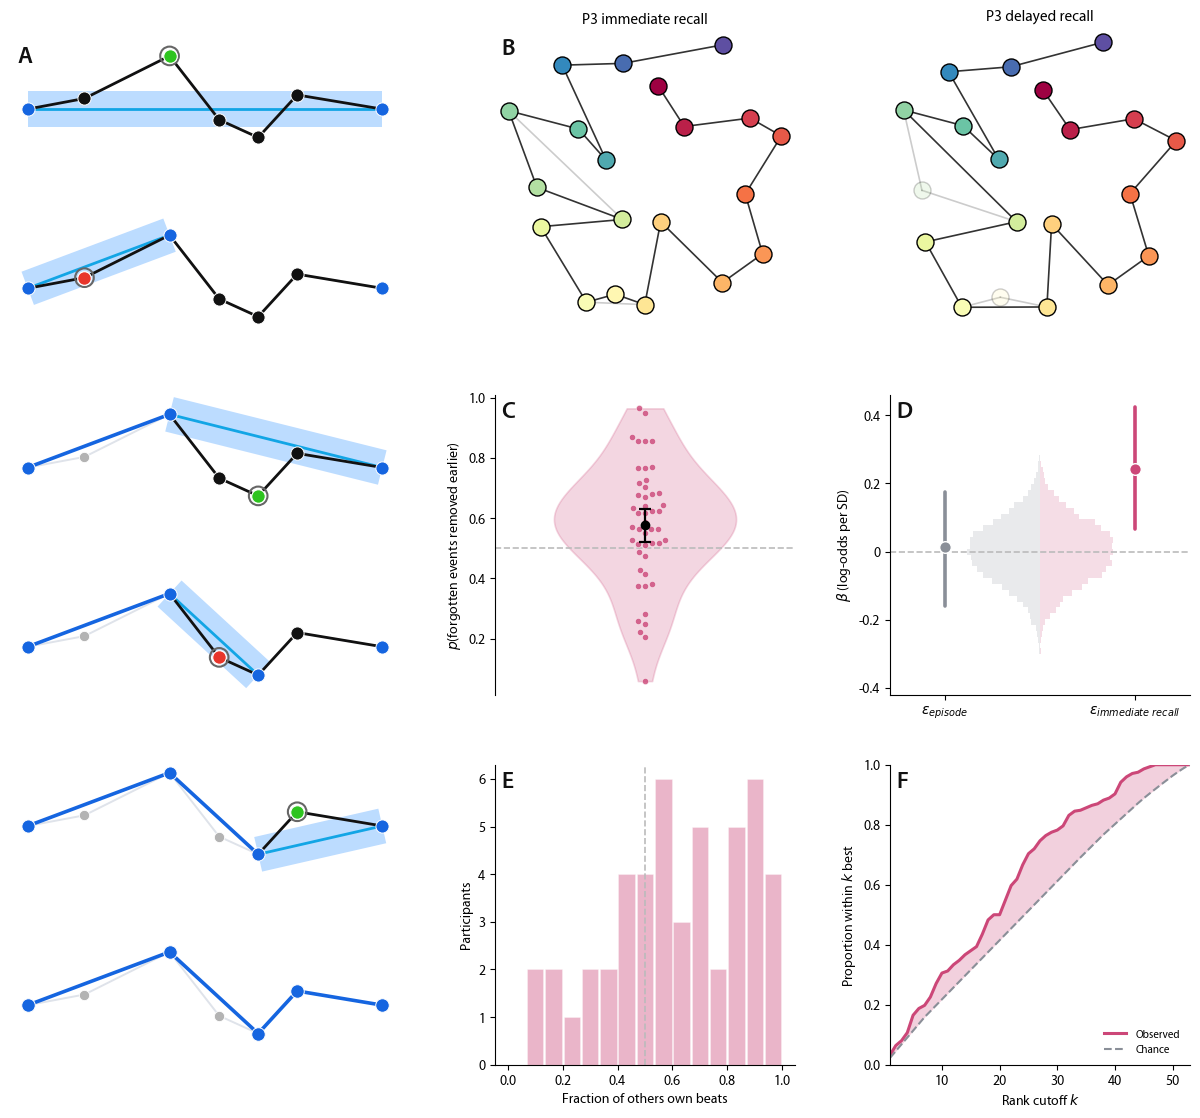

In [306]:
"""Composite figure. Loads cached panel data (figure_panel_data.pkl from
compute_panel_data.py) and only draws -- fast to iterate on visuals.

All recurring colours / alphas / sizes / layout constants live in the CONFIG
block below, so colour-scheme or spacing experiments are one-stop edits.

Layout: cartoon (A, left, full height) + a 2x3 block of squares:
  C  p(forgotten removed earlier) violin     D  own-vs-episode regression
  E  win-rate vs others                      F  own within k best
(B = example participant, top row.)"""
import pickle, numpy as np
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.stats import gaussian_kde
import seaborn as sns

# ============================== CONFIG ==============================
# --- colours ---
C_EFFECT = "#cc4778"   # effect (own prominence): fills + marks across panels C-F
C_COMPARE= "#8a8f98"   # comparison / null: episode (D), chance line (F)
C_REF    = "#bbb"      # dashed reference lines at 0 / 0.5 (C, D, E)
C_TEXT   = "#111"      # panel-letter labels
C_PATH_B = "#333"      # recall-path lines (panel B)
C_DROP_B = "black"     # dropped-event connectors / ghost links (panel B)
C_CIBAR  = "black"     # mean +/- 95% CI bar (panel C)
C_BAND   = "#409bff"   # epsilon band (panel A); at A_BAND over white == #bcdcff
SPEC     = plt.cm.Spectral(np.linspace(0, 1, 20))   # episode colours (panel B dots)
# cartoon palette (panel A)
CA_CURVE="#111"; CA_ENDPT="#1565e0"; CA_CHORD="#12a5e5"
CA_KEEP ="#2ec41f"; CA_DROP="#e8352b"; CA_GHOST="#b3b3b3"; CA_ORIG="#dfe3ea"; CA_RING="#666"

# --- alphas ---
A_VIOLIN = 0.22   # C violin body
A_SWARM  = 0.8    # C per-participant swarm dots
A_CIBAR  = 1.0    # C mean +/- 95% CI bar
A_NULL   = 0.18   # D regression null fills
A_NULLE  = 0.7    # D regression null outlines
A_HIST   = 0.4    # E histogram bars
A_TOPK   = 0.25   # F observed-vs-chance fill
A_GHOST_B= 0.2    # B dropped-event ghosts + shortcut lines
A_BAND   = 0.35   # A epsilon band

# --- sizes / fonts ---
DOT_B       = 150     # panel B event-dot size
LW_B        = 1.2     # panel B path / connector linewidth
LET_FS      = 17      # panel-letter font size
LET_W       = "semibold"
TITLE_FS    = 11      # panel B titles
ANNOT_FS    = 8       # legends
HIST_RWIDTH = 0.9     # E histogram bar-width fraction
NULL_STYLE  = "hist"  # D nulls: "hist" (actual permutation coeffs) or "kde" (smoothed)
NULL_BINS   = 41      # D bin count for the hist style
SWARM_SIZE  = 4.5     # C seaborn swarm marker size (point diameter)
NULL_W      = 0.40    # D half-width of the null histogram (bars extend +/- from 0)
OBS_X       = 0.52    # D x-position of observed estimate + CI (episode -OBS_X, own +OBS_X)
DPI         = 140

# --- layout (inches) ---
S=3.0; Gx=0.95; Gy=0.70; M=0.40; Wc=1.3*S; H=3*S+2*Gy

# --- derived styles ---
ZERO = dict(color=C_REF, ls="--", lw=1.2)   # null / chance reference line
# ===================================================================

DAT = pickle.load(open("figure_panel_data.pkl", "rb"))

# ---------------- cartoon (panel A; cheap to recompute) ----------------
CPATH=np.array([[0.00,0.50],[0.16,0.53],[0.40,0.65],[0.54,0.47],[0.65,0.42],[0.76,0.54],[1.00,0.50]]); CEPS=0.05
CPL=CPR=0.05
def cperp(pts,s,e):
    seg=e-s; L=float(seg@seg)
    if L==0: return np.linalg.norm(pts-s,axis=1)
    t=np.clip((pts-s)@seg/L,0,1); pr=s+t[:,None]*seg; return np.linalg.norm(pts-pr,axis=1)
def ckeep(P,eps):
    def rec(idx):
        if len(idx)<=2: return list(idx)
        dd=cperp(P[idx[1:-1]],P[idx[0]],P[idx[-1]]); k=int(np.argmax(dd))
        if dd[k]>eps: piv=k+1; return rec(idx[:piv+1])[:-1]+rec(idx[piv:])
        return [idx[0],idx[-1]]
    return sorted(rec(list(range(len(P)))))
def csteps(P,eps):
    n=len(P); steps=[]; kept={0,n-1}; dropped=set()
    def rec(lo,hi):
        inner=list(range(lo+1,hi))
        if not inner: return
        dd=cperp(P[inner],P[lo],P[hi]); kk=int(np.argmax(dd)); k=inner[kk]; keep=dd[kk]>eps
        steps.append(dict(lo=lo,hi=hi,test=k,keep=keep,kept=set(kept),dropped=set(dropped)))
        if keep: kept.add(k); rec(lo,k); rec(k,hi)
        else: dropped.update(inner)
    rec(0,n-1); return steps
def cbandpoly(Sp,Ep,eps):
    dd=Ep-Sp; u=dd/np.linalg.norm(dd); p=np.array([-u[1],u[0]]); return np.array([Sp+eps*p,Ep+eps*p,Ep-eps*p,Sp-eps*p])
def draw_cartoon(ax,A):
    xmin,ymin=CPATH.min(0); xmax,ymax=CPATH.max(0); xs=xmax-xmin; ysp=ymax-ymin
    x0=xmin-CPL*xs; x1=xmax+CPR*xs; dx=x1-x0
    steps=csteps(CPATH,CEPS); nn=len(steps)+1; keep=ckeep(CPATH,CEPS); drop=[i for i in range(len(CPATH)) if i not in keep]
    dy=dx/A; mid=(ymin+ymax)/2; YT=mid+dy/2; YB=mid-dy/2; h=ysp; marg=0.03*dy
    c0=YT-marg-h/2; c5=YB+marg+h/2; centers=[c0-i*(c0-c5)/(nn-1) for i in range(nn)]
    def L(Q,idx,c,lw,ls='-',z=1): pts=Q[np.asarray(idx)]; ax.plot(pts[:,0],pts[:,1],ls,color=c,lw=lw,zorder=z,solid_capstyle='round')
    def PT(Q,idx,c,s): [ax.scatter(*Q[i],s=s,color=c,edgecolor='white',lw=0.7,zorder=5) for i in idx]
    def GH(Q,i): ax.scatter(*Q[i],s=55,color=CA_GHOST,edgecolor='white',lw=0.6,zorder=4)
    def RG(Q,i,kp): ax.scatter(*Q[i],s=180,facecolor='none',edgecolor=CA_RING,lw=1.5,zorder=6); ax.scatter(*Q[i],s=95,color=(CA_KEEP if kp else CA_DROP),edgecolor='white',lw=0.8,zorder=7)
    for i in range(nn):
        Q=CPATH+np.array([0.0,centers[i]-mid])
        if i<len(steps):
            st=steps[i]; loo,hii,k,kp=st['lo'],st['hi'],st['test'],st['keep']; kpt,drp=st['kept'],st['dropped']
            L(Q,range(len(CPATH)),CA_ORIG,1.4,z=0.5)   # faint original path: keep dropped points linked to neighbors
            marks=sorted(set(kpt)|{loo,hii})
            for a,b in zip(marks,marks[1:]):
                inr=list(range(a+1,b))
                if inr and all(j in drp for j in inr): L(Q,[a,b],CA_ENDPT,2.6,z=2)
                else: L(Q,range(a,b+1),CA_CURVE,2.0,z=1)
            ax.add_patch(Polygon(cbandpoly(Q[loo],Q[hii],CEPS),closed=True,facecolor=C_BAND,edgecolor='none',alpha=A_BAND,zorder=0))
            ax.plot([Q[loo,0],Q[hii,0]],[Q[loo,1],Q[hii,1]],color=CA_CHORD,lw=2.0,zorder=0.3,solid_capstyle='round')  # chord behind all but band
            for j in range(len(CPATH)):
                if j in drp: GH(Q,j)
                elif j in kpt or j in (loo,hii): PT(Q,[j],CA_ENDPT,90)
                else: PT(Q,[j],CA_CURVE,90)
            RG(Q,k,kp)
        else:
            L(Q,range(len(CPATH)),CA_ORIG,1.4,z=0); L(Q,keep,CA_ENDPT,2.6,z=2)
            for j in drop: GH(Q,j)
            PT(Q,keep,CA_ENDPT,95)
    ax.set_xlim(x0,x1); ax.set_ylim(YB,YT); ax.set_aspect('equal'); ax.axis('off')

# ---------------- layout ----------------
figW=2*M+Wc+2*S+2*Gx; figH=2*M+H
fig=plt.figure(figsize=(figW,figH))
def R(x,y,w,h): return [x/figW,y/figH,w/figW,h/figH]
xA=M+Wc+Gx; xB=xA+S+Gx; top=M+H
def letter(ax,lab): ax.text(0.02,0.98,lab,transform=ax.transAxes,fontsize=LET_FS,fontweight=LET_W,va='top',ha='left',color=C_TEXT,zorder=30)

# A cartoon
axc=fig.add_axes(R(M,M,Wc,H)); draw_cartoon(axc,Wc/H); letter(axc,'A')

# B example participant (P3): events dropped between immediate and delayed recall
imm_path=DAT['P3_imm_path']; imm_mm=DAT['P3_imm_match']; del_path=DAT['P3_del_path']; del_mm=DAT['P3_del_match']
def dotB(ax,xy,ep,alpha=1.0,z=3): ax.scatter(xy[0],xy[1],s=DOT_B,color=SPEC[int(ep)],edgecolor='black',lw=1,alpha=alpha,zorder=z)
axBi=fig.add_axes(R(xA,top-S,S,S))
axBi.plot(imm_path[:,0],imm_path[:,1],'-',color=C_PATH_B,lw=LW_B,zorder=1)
for a,b in [(13,15),(9,11)]:
    p,q=imm_path[a-1],imm_path[b-1]; axBi.plot([p[0],q[0]],[p[1],q[1]],'-',color=C_DROP_B,lw=LW_B,alpha=A_GHOST_B,zorder=1)
for j in range(len(imm_path)): dotB(axBi,imm_path[j],imm_mm[j])
axBi.set_aspect('equal'); axBi.axis('off'); axBi.set_title('P3 immediate recall',fontsize=TITLE_FS); letter(axBi,'B')
axBd=fig.add_axes(R(xB,top-S,S,S))
axBd.plot(del_path[:,0],del_path[:,1],'-',color=C_PATH_B,lw=LW_B,zorder=1)
for imm_i,(dn1,dn2) in [(10,(9,10)),(14,(12,13))]:
    g=imm_path[imm_i-1]
    for dn in (dn1,dn2):
        q=del_path[dn-1]; axBd.plot([g[0],q[0]],[g[1],q[1]],'-',color=C_DROP_B,lw=LW_B,alpha=A_GHOST_B,zorder=1)
    dotB(axBd,g,imm_mm[imm_i-1],alpha=A_GHOST_B,z=2)
for j in range(len(del_path)): dotB(axBd,del_path[j],del_mm[j])
axBd.set_aspect('equal'); axBd.axis('off'); axBd.set_title('P3 delayed recall',fontsize=TITLE_FS)

# C p(forgotten events removed earlier) violin
axC=fig.add_axes(R(xA,top-2*S-Gy,S,S)); aucs=DAT['aucs']; aci=DAT['auc_ci']
parts=axC.violinplot([aucs],positions=[0],vert=True,showextrema=False,widths=0.85)
for pc in parts['bodies']: pc.set_facecolor(C_EFFECT); pc.set_alpha(A_VIOLIN); pc.set_edgecolor(C_EFFECT); pc.set_linewidth(1.2)
sns.swarmplot(y=aucs,ax=axC,color=C_EFFECT,size=SWARM_SIZE,alpha=A_SWARM,edgecolor='white',linewidth=0.4,zorder=3)
axC.axhline(0.5,**ZERO)
axC.errorbar([0],[aucs.mean()],yerr=[[aucs.mean()-aci[0]],[aci[1]-aucs.mean()]],fmt='o',color=C_CIBAR,ms=6,capsize=4,elinewidth=1.6,capthick=1.6,zorder=5,alpha=A_CIBAR)
axC.set_ylabel(r"$p$(forgotten events removed earlier)"); axC.set_xticks([]); axC.set_xlim(-0.7,0.7)
for s in ['top','right','bottom']: axC.spines[s].set_visible(False)
letter(axC,'C')

# D own-vs-episode regression
axD=fig.add_axes(R(xB,top-2*S-Gy,S,S)); Wv=NULL_W; XOBS=OBS_X
on=DAT['reg_null_own']; en=DAT['reg_null_ep']; reg=DAT['reg_coef']; ci_own=DAT['reg_ci_own']; ci_ep=DAT['reg_ci_ep']
_nb=np.linspace(min(on.min(),en.min()),max(on.max(),en.max()),NULL_BINS+1)   # shared bin edges
def vnull(arr,side,c):
    if NULL_STYLE=="kde":
        yv=np.linspace(arr.min(),arr.max(),200); w=gaussian_kde(arr)(yv); w=w/w.max()*Wv
        axD.fill_betweenx(yv,0,side*w,color=c,alpha=A_NULL,lw=0); axD.plot(side*w,yv,color=c,lw=1,alpha=A_NULLE)
    else:  # actual permutation coefficients
        cnt,_=np.histogram(arr,bins=_nb); ctr=0.5*(_nb[:-1]+_nb[1:]); hh=np.diff(_nb); w=cnt/cnt.max()*Wv
        axD.barh(ctr,side*w,height=hh,color=c,alpha=A_NULL,lw=0,align='center')
vnull(on,+1,C_EFFECT); vnull(en,-1,C_COMPARE); axD.axhline(0,**ZERO)
axD.plot([XOBS,XOBS],ci_own,color=C_EFFECT,lw=2.6,solid_capstyle='round'); axD.scatter([XOBS],[reg[1]],s=70,color=C_EFFECT,zorder=4,edgecolor='white',lw=1)
axD.plot([-XOBS,-XOBS],ci_ep,color=C_COMPARE,lw=2.6,solid_capstyle='round'); axD.scatter([-XOBS],[reg[2]],s=70,color=C_COMPARE,zorder=4,edgecolor='white',lw=1)
axD.set_xlim(-0.82,0.82); axD.set_ylim(-0.42,0.46)
axD.set_yticks([-0.4,-0.2,0,0.2,0.4]); axD.set_yticklabels(['-0.4','-0.2','0','0.2','0.4'])
axD.set_xticks([-XOBS,XOBS]); axD.set_xticklabels([r"$\epsilon_{episode}$", r"$\epsilon_{immediate\ recall}$"])
axD.set_ylabel(r"$\beta$ (log-odds per SD)")
for s in ['top','right']: axD.spines[s].set_visible(False)
letter(axD,'D')

# E win-rate vs others
axH=fig.add_axes(R(xA,M,S,S)); axH.hist(DAT['WR'],bins=np.linspace(0,1,16),color=C_EFFECT,alpha=A_HIST,edgecolor='white',lw=0.5,rwidth=HIST_RWIDTH); axH.axvline(0.5,**ZERO)
axH.set_xlabel("Fraction of others own beats"); axH.set_ylabel("Participants")
for s in ['top','right']: axH.spines[s].set_visible(False)
letter(axH,'E')

# F own within k best
axK=fig.add_axes(R(xB,M,S,S)); axK.fill_between(DAT['ks'],DAT['chance'],DAT['observed'],color=C_EFFECT,alpha=A_TOPK,lw=0)
axK.plot(DAT['ks'],DAT['observed'],color=C_EFFECT,lw=2.2,label='Observed'); axK.plot(DAT['ks'],DAT['chance'],'--',color=C_COMPARE,lw=1.5,label='Chance')
axK.set_xlabel(r"Rank cutoff $k$"); axK.set_ylabel(r"Proportion within $k$ best"); axK.set_xlim(1,DAT['M_']); axK.set_ylim(0,1); axK.legend(fontsize=ANNOT_FS,frameon=False,loc='lower right')
for s in ['top','right']: axK.spines[s].set_visible(False)
letter(axK,'F')

# plt.savefig(FIG_DIR / 'rdp-figure-extras.pdf', bbox_inches='tight')


plt.show()